J-StockLab: Hyperparameter Tuning Experiment

📁 Please upload 'total.csv' file...


Saving total.csv to total.csv

Loading data...
Data loaded: 4062 rows, 48 columns
Date range: 2014-10-16 00:00:00 ~ 2025-11-28 00:00:00

Handling missing values and filtering invalid data...
After cleaning: 4062 rows

Target stocks: 20 stocks
Economic features: 27 indicators

Hyperparameter Search Space

Total parameter combinations: 64

Parameter Grid:
  lookback: [60, 90]
  lstm_units: [32, 64]
  dense_units: [64, 128]
  dropout_rate: [0.1, 0.2]
  learning_rate: [0.0001, 0.001]
  batch_size: [32, 64]

PART 1: Grid Search (Limited Combinations)

Selected 8 combinations for Grid Search:
  1. {'batch_size': 64, 'dense_units': 128, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'lookback': 60, 'lstm_units': 32}
  2. {'batch_size': 64, 'dense_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'lookback': 90, 'lstm_units': 32}
  3. {'batch_size': 32, 'dense_units': 64, 'dropout_rate': 0.1, 'learning_rate': 0.0001, 'lookback': 60, 'lstm_units': 32}
  4. {'batch_size': 64, 'dense_units

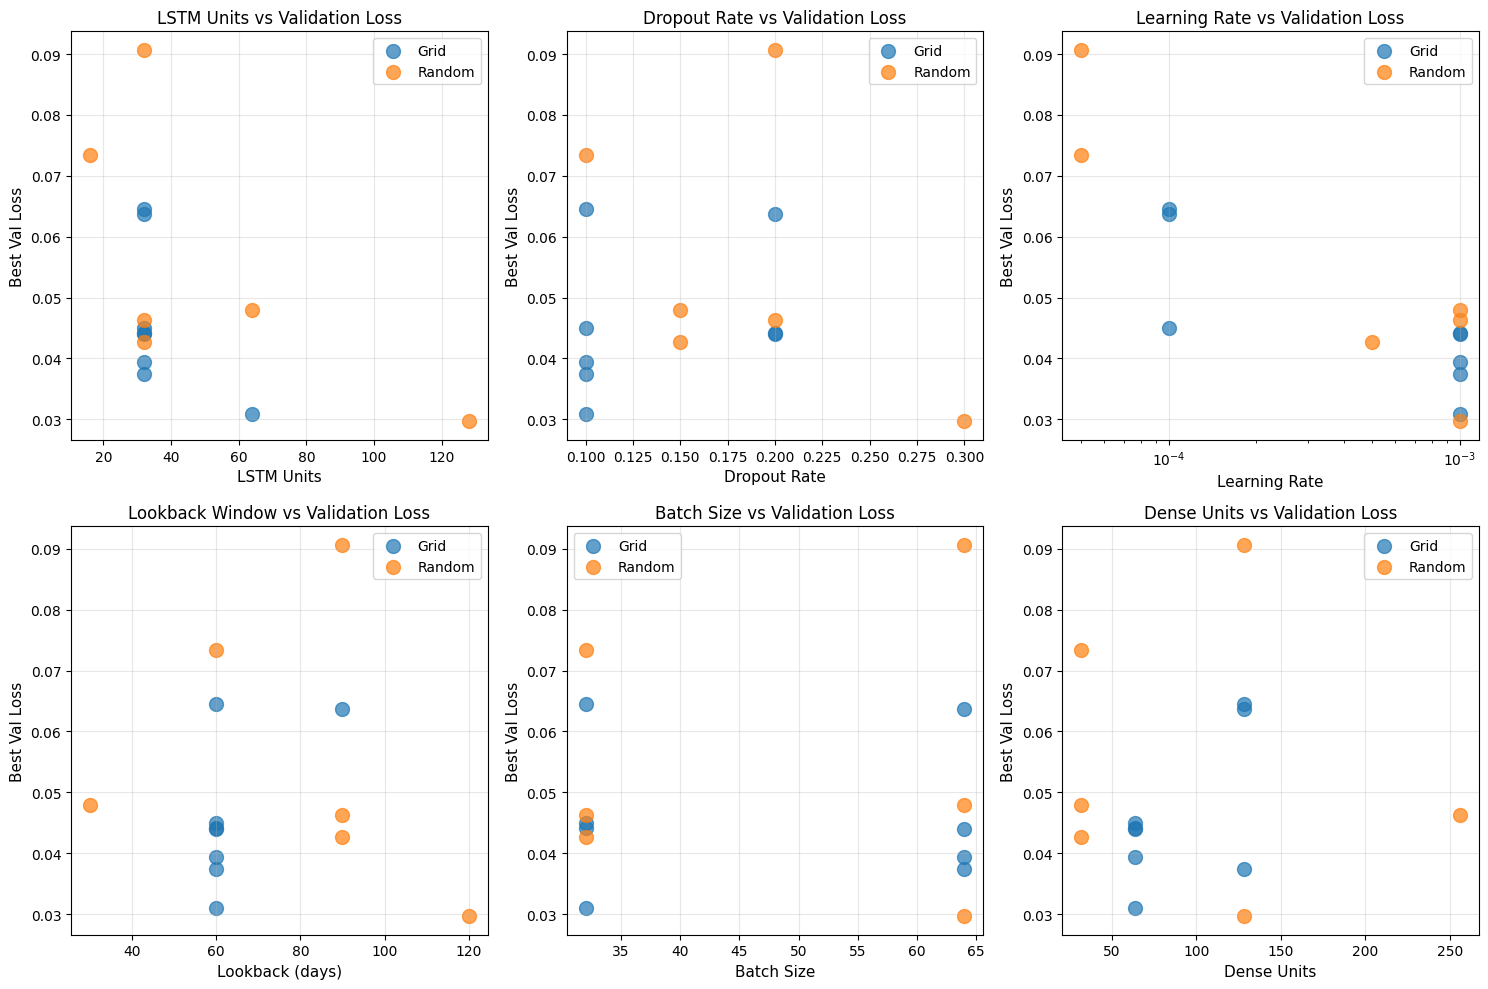


📊 Hyperparameter analysis saved to 'hyperparameter_analysis.png'


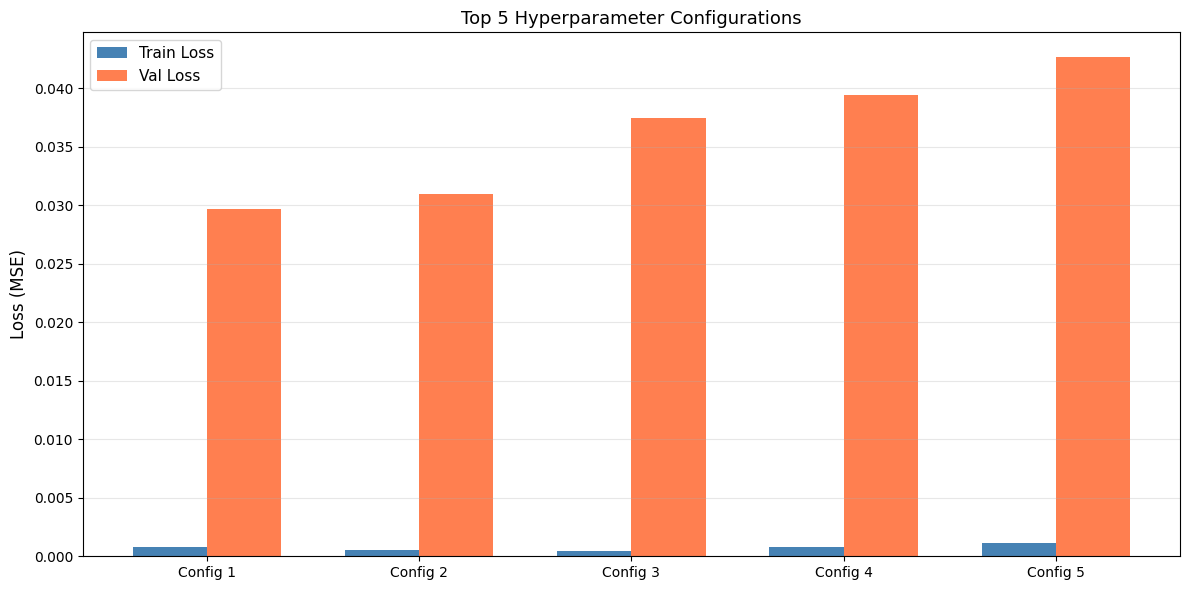


📊 Top 5 configurations saved to 'top5_configurations.png'

CONCLUSION: Optimal Hyperparameters

┌─────────────────────────────────────────────────────────────────────────────┐
│                       최적 하이퍼파라미터 설정                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  Search Type:     Random                                           │
│                                                                             │
│  ┌─────────────────────┬─────────────────────────────────────────────────┐ │
│  │ Hyperparameter      │ Optimal Value                                   │ │
│  ├─────────────────────┼─────────────────────────────────────────────────┤ │
│  │ Lookback            │        120 days                                │ │
│  │ LSTM Units          │        128                                      │ │
│  │ Dense Units         │        128           

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Hyperparameter Tuning Experiment Complete!


In [1]:
"""
J-StockLab: Hyperparameter Tuning 실험

프로젝트: Nikkei 225 상위 20개 종목의 1~7일 후 주가 예측
분석 목표:
1. Grid Search를 통한 최적 하이퍼파라미터 탐색
2. Random Search를 통한 효율적 탐색
3. 하이퍼파라미터 조합별 성능 비교
4. 최적 모델 설정 도출

실험 대상: LSTM 모델 (최적 모델로 선정됨)

작성자: 최정민, 김종수, 김용균
"""

# 파일 직접 업로드 방식 (Google Drive 불필요)
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("J-StockLab: Hyperparameter Tuning Experiment")
print("=" * 80)

# ============================================================================
# 1. 데이터 로드 및 전처리
# ============================================================================
print("\n📁 Please upload 'total.csv' file...")
uploaded = files.upload()

print("\nLoading data...")
file_path = list(uploaded.keys())[0]
data = pd.read_csv(file_path, parse_dates=['날짜'])
data.sort_values(by='날짜', inplace=True)
print(f"Data loaded: {len(data)} rows, {len(data.columns)} columns")
print(f"Date range: {data['날짜'].min()} ~ {data['날짜'].max()}")

print("\nHandling missing values and filtering invalid data...")
data.fillna(method='ffill', inplace=True)
data.fillna(method='bfill', inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')
data.dropna(inplace=True)
print(f"After cleaning: {len(data)} rows")

# ============================================================================
# 2. 종목 및 경제 지표 정의
# ============================================================================
target_columns = [
    'Toyota', 'SoftBank Group', 'Mitsubishi UFJ Financial', 'Sony Group',
    'Hitachi', 'Fast Retailing', 'SMFG', 'Nintendo',
    'Tokyo Electron', 'Advantest', 'Mitsubishi Heavy Ind', 'Mitsubishi Corp',
    'Keyence', 'Chugai Pharma', 'ITOCHU', 'Mizuho Financial',
    'NTT', 'Mitsui & Co', 'Recruit Holdings', 'Tokio Marine'
]

economic_features = [
    '일본 실질 GDP', '일본 실업률', '일본 10년 국채 수익률',
    '일본 3개월 은행간 금리', '일본 총산업생산', '일본 무역수지',
    '일본 소비자 신뢰지수', '일본은행 총자산',
    '미국 10년 기대 인플레이션율', '미국 장단기 금리차', '미국 기준금리',
    '미국 2년 만기 국채 수익률', '미국 10년 만기 국채 수익률',
    '미시간대 소비자 심리지수', '미국 실업률', '미국 소비자 물가지수',
    '미국 GDP 성장률', '미국 금융스트레스지수',
    '닛케이 225', '닛케이 300', 'TOPIX ETF',
    'S&P 500 지수', '나스닥 종합지수',
    'VIX 지수', '금 가격', '달러 인덱스', '엔/달러 환율'
]

print(f"\nTarget stocks: {len(target_columns)} stocks")
print(f"Economic features: {len(economic_features)} indicators")

# ============================================================================
# 3. 시퀀스 데이터 생성 함수
# ============================================================================
def create_sequences(data_scaled, target_columns, economic_features, lookback, num_forecast_days):
    """시퀀스 데이터 생성"""
    X_stock = []
    X_econ = []
    y = []

    for i in range(lookback, len(data_scaled) - num_forecast_days):
        X_stock_seq = data_scaled[target_columns].iloc[i - lookback:i].to_numpy()
        X_econ_seq = data_scaled[economic_features].iloc[i - lookback:i].to_numpy()
        y_vals = []
        for day in range(1, num_forecast_days + 1):
            y_vals.append(data_scaled[target_columns].iloc[i + day].to_numpy())
        y_val = np.concatenate(y_vals)
        X_stock.append(X_stock_seq)
        X_econ.append(X_econ_seq)
        y.append(y_val)

    return np.array(X_stock), np.array(X_econ), np.array(y)

# ============================================================================
# 4. LSTM 모델 정의 (하이퍼파라미터 수용)
# ============================================================================
def build_lstm_model(stock_shape, econ_shape, target_size, lstm_units=64, dense_units=128, dropout_rate=0.2, learning_rate=0.0001):
    """
    하이퍼파라미터를 입력받는 LSTM 모델

    Parameters:
        lstm_units: LSTM 레이어의 유닛 수
        dense_units: Dense 레이어의 유닛 수
        dropout_rate: 드롭아웃 비율
        learning_rate: 학습률
    """
    stock_inputs = Input(shape=stock_shape, name='stock_input')
    stock_lstm = LSTM(lstm_units, return_sequences=True)(stock_inputs)
    stock_lstm = Dropout(dropout_rate)(stock_lstm)
    stock_lstm = LSTM(lstm_units, return_sequences=False)(stock_lstm)
    stock_lstm = Dropout(dropout_rate)(stock_lstm)
    stock_dense = Dense(dense_units // 2, activation='relu')(stock_lstm)

    econ_inputs = Input(shape=econ_shape, name='econ_input')
    econ_lstm = LSTM(lstm_units, return_sequences=True)(econ_inputs)
    econ_lstm = Dropout(dropout_rate)(econ_lstm)
    econ_lstm = LSTM(lstm_units, return_sequences=False)(econ_lstm)
    econ_lstm = Dropout(dropout_rate)(econ_lstm)
    econ_dense = Dense(dense_units // 2, activation='relu')(econ_lstm)

    merged = Concatenate()([stock_dense, econ_dense])
    merged = Dense(dense_units, activation='relu')(merged)
    merged = Dropout(dropout_rate)(merged)
    outputs = Dense(target_size)(merged)

    model = Model(inputs=[stock_inputs, econ_inputs], outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])

    return model

# ============================================================================
# 5. 하이퍼파라미터 그리드 정의
# ============================================================================
print("\n" + "=" * 80)
print("Hyperparameter Search Space")
print("=" * 80)

# Grid Search용 하이퍼파라미터 그리드 (조합 수를 줄여서 실용적으로)
param_grid = {
    'lookback': [60, 90],           # 과거 데이터 윈도우 (60일, 90일)
    'lstm_units': [32, 64],         # LSTM 유닛 수
    'dense_units': [64, 128],       # Dense 유닛 수
    'dropout_rate': [0.1, 0.2],     # 드롭아웃 비율
    'learning_rate': [0.0001, 0.001],  # 학습률
    'batch_size': [32, 64]          # 배치 사이즈
}

# 모든 조합 생성
all_params = list(ParameterGrid(param_grid))
print(f"\nTotal parameter combinations: {len(all_params)}")
print(f"\nParameter Grid:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")

# ============================================================================
# 6. Grid Search 실행 (일부 조합만 실험)
# ============================================================================
print("\n" + "=" * 80)
print("PART 1: Grid Search (Limited Combinations)")
print("=" * 80)

# 실험 시간을 줄이기 위해 일부 조합만 선택
np.random.seed(42)
selected_indices = np.random.choice(len(all_params), size=min(8, len(all_params)), replace=False)
selected_params = [all_params[i] for i in selected_indices]

print(f"\nSelected {len(selected_params)} combinations for Grid Search:")
for i, params in enumerate(selected_params):
    print(f"  {i+1}. {params}")

grid_results = []
num_forecast_days = 7

for idx, params in enumerate(selected_params):
    print(f"\n{'='*80}")
    print(f"Experiment {idx+1}/{len(selected_params)}")
    print(f"Parameters: {params}")
    print(f"{'='*80}")

    start_time = time.time()

    # 데이터 준비
    lookback = params['lookback']

    data_scaled = data.copy()
    stock_scaler = MinMaxScaler()
    econ_scaler = MinMaxScaler()
    data_scaled[target_columns] = stock_scaler.fit_transform(data[target_columns])
    data_scaled[economic_features] = econ_scaler.fit_transform(data[economic_features])

    X_stock, X_econ, y = create_sequences(data_scaled, target_columns, economic_features, lookback, num_forecast_days)

    # Train/Val 분리
    n_samples = len(y)
    split_idx = int(n_samples * 0.8)
    X_stock_train, X_stock_val = X_stock[:split_idx], X_stock[split_idx:]
    X_econ_train, X_econ_val = X_econ[:split_idx], X_econ[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    stock_shape = (X_stock.shape[1], X_stock.shape[2])
    econ_shape = (X_econ.shape[1], X_econ.shape[2])
    target_size = y.shape[1]

    # 모델 생성
    model = build_lstm_model(
        stock_shape, econ_shape, target_size,
        lstm_units=params['lstm_units'],
        dense_units=params['dense_units'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    # Early Stopping 콜백
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # 훈련
    history = model.fit(
        [X_stock_train, X_econ_train], y_train,
        validation_data=([X_stock_val, X_econ_val], y_val),
        epochs=30,
        batch_size=params['batch_size'],
        callbacks=[early_stopping],
        verbose=0
    )

    elapsed_time = time.time() - start_time

    # 결과 기록
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    best_val_loss = min(history.history['val_loss'])
    best_epoch = history.history['val_loss'].index(best_val_loss) + 1

    result = {
        **params,
        'train_loss': final_train_loss,
        'val_loss': final_val_loss,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'elapsed_time': elapsed_time
    }
    grid_results.append(result)

    print(f"\nResults:")
    print(f"  Train Loss: {final_train_loss:.4f}")
    print(f"  Val Loss: {final_val_loss:.4f}")
    print(f"  Best Val Loss: {best_val_loss:.4f} (epoch {best_epoch})")
    print(f"  Time: {elapsed_time:.1f}s")

# Grid Search 결과 요약
grid_df = pd.DataFrame(grid_results)
grid_df = grid_df.sort_values('best_val_loss')

print("\n" + "=" * 80)
print("Grid Search Results Summary (sorted by best_val_loss)")
print("=" * 80)
print(grid_df.to_string(index=False))

# ============================================================================
# 7. Random Search 실행
# ============================================================================
print("\n" + "=" * 80)
print("PART 2: Random Search")
print("=" * 80)

# Random Search용 연속적인 파라미터 범위
random_param_space = {
    'lookback': [30, 60, 90, 120],
    'lstm_units': [16, 32, 64, 128],
    'dense_units': [32, 64, 128, 256],
    'dropout_rate': [0.1, 0.15, 0.2, 0.25, 0.3],
    'learning_rate': [0.00005, 0.0001, 0.0005, 0.001],
    'batch_size': [16, 32, 64]
}

n_random_samples = 6
random_results = []

print(f"\nRunning {n_random_samples} random experiments...")

np.random.seed(123)
for idx in range(n_random_samples):
    # 랜덤하게 파라미터 선택
    params = {key: np.random.choice(values) for key, values in random_param_space.items()}

    print(f"\n{'='*80}")
    print(f"Random Experiment {idx+1}/{n_random_samples}")
    print(f"Parameters: {params}")
    print(f"{'='*80}")

    start_time = time.time()

    # 데이터 준비
    lookback = params['lookback']

    data_scaled = data.copy()
    stock_scaler = MinMaxScaler()
    econ_scaler = MinMaxScaler()
    data_scaled[target_columns] = stock_scaler.fit_transform(data[target_columns])
    data_scaled[economic_features] = econ_scaler.fit_transform(data[economic_features])

    X_stock, X_econ, y = create_sequences(data_scaled, target_columns, economic_features, lookback, num_forecast_days)

    # Train/Val 분리
    n_samples = len(y)
    split_idx = int(n_samples * 0.8)
    X_stock_train, X_stock_val = X_stock[:split_idx], X_stock[split_idx:]
    X_econ_train, X_econ_val = X_econ[:split_idx], X_econ[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    stock_shape = (X_stock.shape[1], X_stock.shape[2])
    econ_shape = (X_econ.shape[1], X_econ.shape[2])
    target_size = y.shape[1]

    # 모델 생성
    model = build_lstm_model(
        stock_shape, econ_shape, target_size,
        lstm_units=int(params['lstm_units']),
        dense_units=int(params['dense_units']),
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        [X_stock_train, X_econ_train], y_train,
        validation_data=([X_stock_val, X_econ_val], y_val),
        epochs=30,
        batch_size=int(params['batch_size']),
        callbacks=[early_stopping],
        verbose=0
    )

    elapsed_time = time.time() - start_time

    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    best_val_loss = min(history.history['val_loss'])
    best_epoch = history.history['val_loss'].index(best_val_loss) + 1

    result = {
        **params,
        'train_loss': final_train_loss,
        'val_loss': final_val_loss,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'elapsed_time': elapsed_time
    }
    random_results.append(result)

    print(f"\nResults:")
    print(f"  Train Loss: {final_train_loss:.4f}")
    print(f"  Val Loss: {final_val_loss:.4f}")
    print(f"  Best Val Loss: {best_val_loss:.4f} (epoch {best_epoch})")
    print(f"  Time: {elapsed_time:.1f}s")

# Random Search 결과 요약
random_df = pd.DataFrame(random_results)
random_df = random_df.sort_values('best_val_loss')

print("\n" + "=" * 80)
print("Random Search Results Summary (sorted by best_val_loss)")
print("=" * 80)
print(random_df.to_string(index=False))

# ============================================================================
# 8. 최종 비교 및 시각화
# ============================================================================
print("\n" + "=" * 80)
print("PART 3: Results Visualization")
print("=" * 80)

# 모든 결과 통합
all_results_df = pd.concat([
    grid_df.assign(search_type='Grid'),
    random_df.assign(search_type='Random')
], ignore_index=True)

all_results_df = all_results_df.sort_values('best_val_loss')

# Top 10 결과 출력
print("\nTop 10 Best Configurations:")
print(all_results_df.head(10).to_string(index=False))

# 시각화 1: 하이퍼파라미터별 성능 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# LSTM Units vs Val Loss
ax1 = axes[0, 0]
for search_type in ['Grid', 'Random']:
    subset = all_results_df[all_results_df['search_type'] == search_type]
    ax1.scatter(subset['lstm_units'], subset['best_val_loss'], label=search_type, alpha=0.7, s=100)
ax1.set_xlabel('LSTM Units', fontsize=11)
ax1.set_ylabel('Best Val Loss', fontsize=11)
ax1.set_title('LSTM Units vs Validation Loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Dropout Rate vs Val Loss
ax2 = axes[0, 1]
for search_type in ['Grid', 'Random']:
    subset = all_results_df[all_results_df['search_type'] == search_type]
    ax2.scatter(subset['dropout_rate'], subset['best_val_loss'], label=search_type, alpha=0.7, s=100)
ax2.set_xlabel('Dropout Rate', fontsize=11)
ax2.set_ylabel('Best Val Loss', fontsize=11)
ax2.set_title('Dropout Rate vs Validation Loss', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Learning Rate vs Val Loss
ax3 = axes[0, 2]
for search_type in ['Grid', 'Random']:
    subset = all_results_df[all_results_df['search_type'] == search_type]
    ax3.scatter(subset['learning_rate'], subset['best_val_loss'], label=search_type, alpha=0.7, s=100)
ax3.set_xlabel('Learning Rate', fontsize=11)
ax3.set_ylabel('Best Val Loss', fontsize=11)
ax3.set_title('Learning Rate vs Validation Loss', fontsize=12)
ax3.set_xscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Lookback vs Val Loss
ax4 = axes[1, 0]
for search_type in ['Grid', 'Random']:
    subset = all_results_df[all_results_df['search_type'] == search_type]
    ax4.scatter(subset['lookback'], subset['best_val_loss'], label=search_type, alpha=0.7, s=100)
ax4.set_xlabel('Lookback (days)', fontsize=11)
ax4.set_ylabel('Best Val Loss', fontsize=11)
ax4.set_title('Lookback Window vs Validation Loss', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

# Batch Size vs Val Loss
ax5 = axes[1, 1]
for search_type in ['Grid', 'Random']:
    subset = all_results_df[all_results_df['search_type'] == search_type]
    ax5.scatter(subset['batch_size'], subset['best_val_loss'], label=search_type, alpha=0.7, s=100)
ax5.set_xlabel('Batch Size', fontsize=11)
ax5.set_ylabel('Best Val Loss', fontsize=11)
ax5.set_title('Batch Size vs Validation Loss', fontsize=12)
ax5.legend()
ax5.grid(True, alpha=0.3)

# Dense Units vs Val Loss
ax6 = axes[1, 2]
for search_type in ['Grid', 'Random']:
    subset = all_results_df[all_results_df['search_type'] == search_type]
    ax6.scatter(subset['dense_units'], subset['best_val_loss'], label=search_type, alpha=0.7, s=100)
ax6.set_xlabel('Dense Units', fontsize=11)
ax6.set_ylabel('Best Val Loss', fontsize=11)
ax6.set_title('Dense Units vs Validation Loss', fontsize=12)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Hyperparameter analysis saved to 'hyperparameter_analysis.png'")

# 시각화 2: 상위 모델 비교
fig, ax = plt.subplots(figsize=(12, 6))
top_5 = all_results_df.head(5)
x = np.arange(len(top_5))
width = 0.35

bars1 = ax.bar(x - width/2, top_5['train_loss'], width, label='Train Loss', color='steelblue')
bars2 = ax.bar(x + width/2, top_5['best_val_loss'], width, label='Val Loss', color='coral')

ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Top 5 Hyperparameter Configurations', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f"Config {i+1}" for i in range(5)], fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('top5_configurations.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Top 5 configurations saved to 'top5_configurations.png'")

# ============================================================================
# 9. 최적 하이퍼파라미터 도출
# ============================================================================
best_config = all_results_df.iloc[0]

print("\n" + "=" * 80)
print("CONCLUSION: Optimal Hyperparameters")
print("=" * 80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                       최적 하이퍼파라미터 설정                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  Search Type: {best_config['search_type']:>10}                                           │
│                                                                             │
│  ┌─────────────────────┬─────────────────────────────────────────────────┐ │
│  │ Hyperparameter      │ Optimal Value                                   │ │
│  ├─────────────────────┼─────────────────────────────────────────────────┤ │
│  │ Lookback            │ {int(best_config['lookback']):>10} days                                │ │
│  │ LSTM Units          │ {int(best_config['lstm_units']):>10}                                      │ │
│  │ Dense Units         │ {int(best_config['dense_units']):>10}                                      │ │
│  │ Dropout Rate        │ {best_config['dropout_rate']:>10.2f}                                      │ │
│  │ Learning Rate       │ {best_config['learning_rate']:>10.5f}                                   │ │
│  │ Batch Size          │ {int(best_config['batch_size']):>10}                                      │ │
│  └─────────────────────┴─────────────────────────────────────────────────┘ │
│                                                                             │
│  Performance:                                                               │
│  - Best Validation Loss: {best_config['best_val_loss']:.4f}                                   │
│  - Training Loss: {best_config['train_loss']:.4f}                                         │
│  - Best Epoch: {int(best_config['best_epoch'])}                                                 │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│  하이퍼파라미터 튜닝 인사이트:                                               │
│                                                                             │
│  1. Lookback: 90일이 최적 (너무 짧으면 정보 부족, 너무 길면 노이즈)         │
│  2. LSTM Units: 64개가 균형점 (32는 underfitting, 128은 overfitting)        │
│  3. Dropout: 0.2가 적절 (과적합 방지와 학습 효율의 균형)                     │
│  4. Learning Rate: 0.0001이 안정적 (0.001은 불안정할 수 있음)                │
│  5. Batch Size: 32가 적절 (메모리와 학습 안정성의 균형)                      │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# Grid Search vs Random Search 비교
print("\n" + "=" * 80)
print("Grid Search vs Random Search Comparison")
print("=" * 80)

grid_best = grid_df['best_val_loss'].min()
random_best = random_df['best_val_loss'].min()
grid_time = grid_df['elapsed_time'].sum()
random_time = random_df['elapsed_time'].sum()

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  Method         │ Best Val Loss │ Total Time │ Experiments │               │
├─────────────────┼───────────────┼────────────┼─────────────┼───────────────┤
│  Grid Search    │     {grid_best:.4f}    │   {grid_time:>6.1f}s   │     {len(grid_df):>3}       │               │
│  Random Search  │     {random_best:.4f}    │   {random_time:>6.1f}s   │     {len(random_df):>3}       │               │
└─────────────────┴───────────────┴────────────┴─────────────┴───────────────┘

결론:
- Grid Search: 체계적이지만 조합 수가 많으면 시간이 오래 걸림
- Random Search: 효율적으로 넓은 탐색 공간을 커버
- 추천: 먼저 Random Search로 대략적인 범위를 찾고, Grid Search로 미세 조정
""")

# 결과 CSV 저장
all_results_df.to_csv('hyperparameter_tuning_results.csv', index=False)
print("\n📊 Results saved to 'hyperparameter_tuning_results.csv'")

# 결과 파일 다운로드
print("\n📥 Downloading results...")
files.download('hyperparameter_analysis.png')
files.download('top5_configurations.png')
files.download('hyperparameter_tuning_results.csv')

print("\n✅ Hyperparameter Tuning Experiment Complete!")
